In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

/tmp/ipykernel_97107/2026922495.py:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [12]:
def build_and_train_model(x,y):
    ANNreg = nn.Sequential(
        nn.Linear(1,1), #input
        nn.ReLU(), #activation
        nn.Linear(1,1) #output
    )
    lr = .05
    loss_func = nn.MSELoss()
    optimizer = torch.optim.SGD(ANNreg.parameters(), lr = lr)
    num_of_epochs = 500
    losses = np.zeros(num_of_epochs)
    for epochi in range(num_of_epochs):
        y_hat = ANNreg(x)
        loss = loss_func(y_hat, y)
        losses[epochi] = loss
        #back propogation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    predictions = ANNreg(x)
    #testloss = (predictions-y).pow(2).mean()
    return predictions, losses

In [28]:
def create_x_and_y(N,m):
    x = torch.randn(N, 1)
    y = m*x + torch.randn(N, 1)/2
    return x,y

Test it once

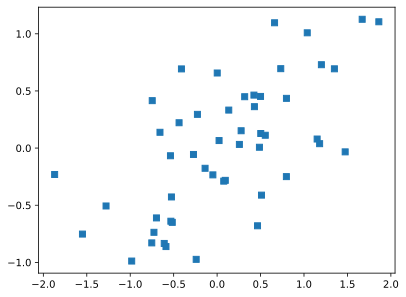

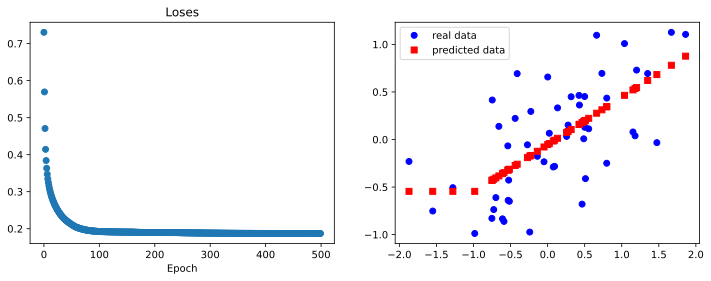

In [18]:
x,y = create_x_and_y(50,.5)
predictions, losses = build_and_train_model(x,y)

fig,ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(losses, 'o')
ax[0].set_xlabel('Epoch')
ax[0].set_title('Loses')

ax[1].plot(x,y,'bo', label='real data')
ax[1].plot(x,predictions.detach().numpy(),'rs', label='predicted data')
ax[1].legend()
plt.show()

In [30]:
#slopes = np.linspace(-2, 2, 21)
results=np.zeros((21, 50, 2))
for i_idx,i in enumerate(np.linspace(-2, 2, 21)):
    for j in range(50):
        x, y = create_x_and_y(50,i)
        predictions, testloss = build_and_train_model(x,y)
        results[i_idx,j,0] = testloss[-1]
        results[i_idx,j,1] = np.corrcoef(y.T, predictions.detach().T)[0,1]
results[np.isnan(results)] = 0


/tmp/ipykernel_97107/3307305882.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


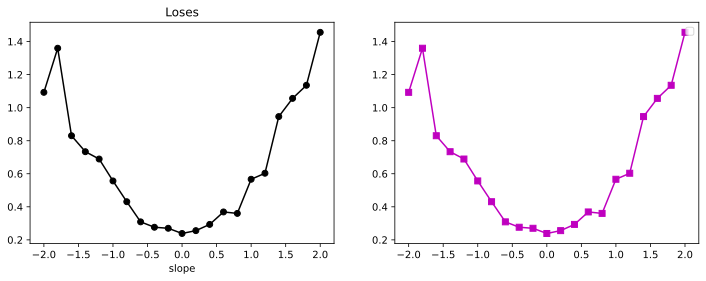

In [31]:
slopes = np.linspace(-2, 2, 21)
fig,ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(slopes, np.mean(results[:,:,0], axis=1), 'ko-')
ax[0].set_xlabel('slope')
ax[0].set_title('Loses')

ax[1].plot(slopes, np.mean(results[:,:,0], axis=1), 'ms-')
#ax[1].plot(x,predictions.detach().numpy(),'rs', label='predicted data')
ax[1].legend()
plt.show()